In [2]:
from IPython.display import HTML
# SET UP STANDARDISED FORMATTING
display(HTML("""
<style>
.body-text {
    font-size: 18px;
}
</style>
"""))

<h1>Overview</h1>
<span class="body-text">

The EDA phase will be split into two notebooks due to the complexity of some of the datasets.
This notebook will contain exploratory data analysis of the **Net Overseas Migration** dataset.
The analysis will go through the following phases:
<ol>
<li>Select the states Victoria and New South Wales to focus on for migration and their relation to the housing prices in those states.</li>
<li>Statistically and visually, prove the positive correlation between net migration to a state and its median housing prices.</li>
<li>Forecast what is likely to happen in the coming years.</li>
</ol>
</span>


<span class="body-text">We will select the net migration data over the reference period for the states Victoria (VIC) and New South Wales (NSW).
This data will be used in our time series analysis and visualisation.</span>

In [3]:
import pandas as pd

migration_data = pd.read_csv('../data/migration_data.csv')
migration_data = migration_data.iloc[:, 1:]
print(migration_data.shape)
migration_data.head()

(300, 5)


,Arrival,Departure,Total,Year,State-Territory
0,75020,-39100,35920,2006,New South Wales
1,51670,-23810,27860,2006,Victoria
2,41240,-21250,19980,2006,Queensland
3,11820,-4640,7180,2006,South Australia
4,26430,-11520,14910,2006,Western Australia


<h4>Modifying the migration data</h4>
<span class="body-text">Our migration data needs a little preprocessing to get it into a DataFrame that can easily be operated with for analysis.</span>

In [4]:
migration_data_reshaped = migration_data.groupby(['Year', 'State-Territory'])['Total'].mean()
cols_to_drop = ['Christmas Island', 'Cocos (Keeling) Islands', 'Jervis Bay', 'Norfolk Island', 'Not Stated', 'Other Territories', 'Total']
migration_data_reshaped = migration_data_reshaped.drop(labels=cols_to_drop, level='State-Territory')
migration_data_reshaped = migration_data_reshaped.unstack(level=1)
migration_data_reshaped.index = pd.to_datetime(migration_data_reshaped.index, format='%Y')
migration_data_reshaped

State-Territory,Australian Capital Territory,New South Wales,Northern Territory,Queensland,South Australia,Tasmania,Victoria,Western Australia
Year,,,,,,,,
2006-01-01,670.0,35920.0,260.0,19980.0,7180.0,800.0,27860.0,14910.0
2007-01-01,1880.0,76900.0,1380.0,47680.0,13830.0,1470.0,66470.0,34430.0
2008-01-01,3330.0,96430.0,1970.0,62840.0,17620.0,2090.0,83230.0,48190.0
2009-01-01,3670.0,70160.0,1690.0,47330.0,17170.0,1930.0,72090.0,32840.0
2010-01-01,2000.0,50040.0,1090.0,31670.0,10890.0,1230.0,43210.0,31900.0
2011-01-01,3050.0,54170.0,2070.0,40920.0,10430.0,1250.0,51060.0,43280.0
2012-01-01,3560.0,63140.0,4120.0,47260.0,11870.0,1580.0,58750.0,49970.0
2013-01-01,2650.0,67580.0,3190.0,33460.0,12130.0,1790.0,58500.0,29060.0
2014-01-01,3210.0,68350.0,1140.0,23030.0,10970.0,1730.0,58390.0,15510.0


<h4>Fetching population data</h4>

<span style="font-size: 18px">We need population data in order to calculate per capital migration, which as we will justify later, is a more accurate metric for migration across vastly different states compared to a raw migration figure. </span>

In [5]:
# calculate the net migration per 1000 residents before calculating percentage change
population_data = pd.read_csv('../data/population_data.csv')
population_data.index = population_data.pop('Quarter')
population_data.index = pd.to_datetime(population_data.index)
# store the national population in each year separately
national_population = population_data.pop('Australia')
print(population_data.shape)
print(population_data.index)
population_data.head()

(177, 8)
DatetimeIndex(['1981-06-01', '1981-09-01', '1981-12-01', '1982-03-01',
               '1982-06-01', '1982-09-01', '1982-12-01', '1983-03-01',
               '1983-06-01', '1983-09-01',
               ...
               '2023-03-01', '2023-06-01', '2023-09-01', '2023-12-01',
               '2024-03-01', '2024-06-01', '2024-09-01', '2024-12-01',
               '2025-03-01', '2025-06-01'],
              dtype='datetime64[ns]', name='Quarter', length=177, freq=None)


,New South Wales,Victoria,Queensland,South Australia,Western Australia,Tasmania,Northern Territory,Australian Capital Territory
Quarter,,,,,,,,
1981-06-01,5234889,3946917,2345208,1318769,1300056,427224,122616,227581
1981-09-01,5249455,3957333,2367477,1321235,1311284,427925,125186,228782
1981-12-01,5266894,3968398,2387943,1325176,1320221,428283,127718,229484
1982-03-01,5286119,3980826,2406355,1328670,1329700,429445,129593,230990
1982-06-01,5303580,3992870,2424586,1331108,1338899,429845,130314,233045


<h4> Intermediate step: Synchronising time index</h4>

<span style="font-size: 18px">In order for our vectorized calculation of per capita migration to work, we need the time indices to be the same. Since the migration data only goes back to 2006, our population data must be restricted to 2006 at earliest.</span>

In [6]:
population_data = population_data.loc[population_data.index.year >= 2006]

# aggregate the data from a quarterly to a yearly frequency
population_data = population_data.groupby(population_data.index.year)[population_data.columns].nth(1)
population_data

,New South Wales,Victoria,Queensland,South Australia,Western Australia,Tasmania,Northern Territory,Australian Capital Territory
Quarter,,,,,,,,
2006-06-01,6742690,5061266,4007992,1552529,2050581,489302,209057,335170
2007-06-01,6834156,5153522,4111018,1570619,2106139,493262,213748,342644
2008-06-01,6943461,5256375,4219505,1588665,2171700,498568,219874,348368
2009-06-01,7053755,5371934,4328771,1608902,2240250,504353,226027,354785
2010-06-01,7144292,5461101,4404744,1627322,2290845,508847,229778,361766
2011-06-01,7218529,5537817,4476778,1639614,2353409,511483,231292,367985
2012-06-01,7304244,5651091,4568687,1656725,2425507,511724,235915,376539
2013-06-01,7404032,5772669,4652824,1671488,2486944,512231,241722,383257
2014-06-01,7508353,5894917,4719653,1686945,2517608,513621,242894,388799


<h2>Objective: Obtain a suitable metric for determining the rate of migration within different states/territories</h2>
<span style="font-size: 18px">We have decided to look at net migration on a </strong>per capita basis</strong>.
<h4> Our reasoning:</h4>
<ul style="font-size: 18px; list-style-type: square">
<li>Different states have <strong>different scales</strong> for the amount of migration that occurs due to their different populations.</li>
<li>For example, New South Wales will definitely have a higher absolute value for net migration, but when calculating percentage change in net migration, its large volume of migrants yearly might dilute the signal.</li>
<li>On the other hand, the Northern Territory (NT) does not get as many migrants so even a small increase could warrant very large percentage increases.</li>
</ul>

<span style="font-size: 18px">Our aim is to not end up with misleading data, precisely by using this officially endorsed metric for migration.</span>

<span style="font-size: 18px">
$$
\text{Net Overseas Migration Per 1000 Residents} = \frac{\text{Net Overseas Migration}}{\text{Population of State}}
$$
</span>

In [7]:
# the population and migration data have their column orders mismatched. this must be fixed
migration_data_reshaped = migration_data_reshaped[population_data.columns]
migration_per_capita = pd.DataFrame(migration_data_reshaped.values / population_data.values * 1000, index=migration_data_reshaped.index, columns=migration_data_reshaped.columns)
migration_per_capita

State-Territory,New South Wales,Victoria,Queensland,South Australia,Western Australia,Tasmania,Northern Territory,Australian Capital Territory
Year,,,,,,,,
2006-01-01,5.327251,5.504552,4.985040,4.624712,7.271110,1.634982,1.243680,1.998986
2007-01-01,11.252304,12.897975,11.598101,8.805445,16.347449,2.980161,6.456201,5.486744
2008-01-01,13.887887,15.834106,14.892742,11.091073,22.189989,4.192006,8.959677,9.558857
2009-01-01,9.946475,13.419748,10.933819,10.671874,14.659078,3.826685,7.476983,10.344293
2010-01-01,7.004193,7.912324,7.189975,6.691976,13.924993,2.417230,4.743709,5.528436
2011-01-01,7.504299,9.220240,9.140502,6.361253,18.390344,2.443874,8.949726,8.288381
2012-01-01,8.644290,10.396223,10.344329,7.164738,20.601878,3.087602,17.463917,9.454532
2013-01-01,9.127459,10.133961,7.191332,7.257007,11.685024,3.494517,13.196978,6.914420
2014-01-01,9.103195,9.905144,4.879596,6.502879,6.160610,3.368242,4.693405,8.256194


<h4>Fetching dataset for median house prices and number of transfers</h4>
<span class="body-text">We are now retrieving our house prices data, alongside our number of transfers data. The latter will be useful for estimating median prices on a state and national level since we don't have this information directly available to us through any dataset.</span>

In [8]:
house_prices_and_transfers = pd.read_csv('../data/median_price_data.csv')
house_prices_and_transfers.index = pd.to_datetime(house_prices_and_transfers.pop('Quarter'))
house_prices_and_transfers

,Median Price of Established House Transfers (Unstratified) ; Sydney ;,Median Price of Established House Transfers (Unstratified) ; Rest of NSW ;,Median Price of Established House Transfers (Unstratified) ; Melbourne ;,Median Price of Established House Transfers (Unstratified) ; Rest of Vic. ;,Median Price of Established House Transfers (Unstratified) ; Brisbane ;,Median Price of Established House Transfers (Unstratified) ; Rest of Qld. ;,Median Price of Established House Transfers (Unstratified) ; Adelaide ;,Median Price of Established House Transfers (Unstratified) ; Rest of SA ;,Median Price of Established House Transfers (Unstratified) ; Perth ;,Median Price of Established House Transfers (Unstratified) ; Rest of WA ;,...,Number of Attached Dwelling Transfers ; Rest of Qld. ;,Number of Attached Dwelling Transfers ; Adelaide ;,Number of Attached Dwelling Transfers ; Rest of SA ;,Number of Attached Dwelling Transfers ; Perth ;,Number of Attached Dwelling Transfers ; Rest of WA ;,Number of Attached Dwelling Transfers ; Hobart ;,Number of Attached Dwelling Transfers ; Rest of Tas. ;,Number of Attached Dwelling Transfers ; Darwin ;,Number of Attached Dwelling Transfers ; Rest of NT ;,Number of Attached Dwelling Transfers ; Canberra ;
Quarter,,,,,,,,,,,,,,,,,,,,,
2002-03-01,365.0,NaN,241.0,NaN,185.0,NaN,166.0,NaN,190.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-06-01,393.5,NaN,260.0,NaN,182.6,NaN,175.0,NaN,190.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-09-01,413.0,NaN,265.0,NaN,198.0,NaN,181.0,NaN,195.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-12-01,444.0,NaN,280.0,NaN,208.0,NaN,195.0,NaN,206.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-03-01,434.5,NaN,270.0,NaN,225.0,NaN,209.4,NaN,216.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-01,1410.0,745.0,825.0,559.0,890.0,649.0,818.3,465.0,780.0,495.0,...,6199.0,2238.0,296.0,3810.0,510.0,296.0,285.0,237.0,27.0,1014.0
2024-12-01,1452.5,760.0,852.0,560.0,935.0,675.0,850.0,500.0,820.0,520.0,...,5820.0,2191.0,275.0,3647.0,507.0,319.0,314.0,245.0,29.0,1098.0
2025-03-01,1450.0,760.0,840.0,575.0,945.0,710.0,855.0,485.0,820.3,540.0,...,5677.0,2013.0,239.0,3519.0,454.0,355.0,284.0,245.0,31.0,1088.0


<h2>Key Limitations</h2>
<span style="font-size: 18px;">
<ul style="list-style-type: square; font-size: 18px; ">
<li> Since our migration data is only split by states, we will need to find a way to combine the percentage changes in the median price data for data within a capital city versus in the rest of the state the capital city belongs to. </li>
<li> Since regional parts of a state are not contributing equally to the capital city for a state's median price, we will need a **weighted average**. </li>
 <li> This is where the number of transfers of buildings comes in handy. The contribution of a region to the median price is related to how many house transfers are involved within it. </li>
</span>
</ul>
<span style="font-size: 18px;"> We will use two average formulas to get reasonable approximations of the median prices across each state given the limitations of our data. </span>

<h2>Justifications</h2>
<ul style="list-style-type: square; font-size: 18px;">
<li>Since we don't have access to pricing and transfer data from all residential building types, we need approximations.</li>
<li>We take a <strong>weighted average</strong> when calculating median price per region rather than a simple halfway average because we don't expect established houses and detached dwellings to contribute equally to an area's median house prices or number of transfers.</li>
<li>We also take a <strong>weighted average</strong> when calculating median price per state because we expect capital cities to contribute more in median pricing and number of transfers for a state than any other place within the state.</li>
</ul>
<span style="font-size: 18px;" > First step is to calculate the median price changes for each of the capital cities and then each of the regions outside the capital city (eg. rest of NSW, rest of VIC etc.). We will call these <strong>regions</strong>. </span>
<span style="font-size: 24px">
\begin{align}
P_r = \frac{n_{r, e} \times p_{r, e} + n_{r, d} \times p_{r, d}}{n_{r, e}+n_{r, d}}
\end{align}
</span>



<span style="font-size: 24px;"> Variables </span>

<table style="width: 90%; margin-left: auto; margin-right: auto; border-collapse: collapse; font-size: 16px;">
  <tr>
    <th style="padding: 10px; border: 1px solid #ccc; font-size: 18px;">Term</th>
    <th style="padding: 10px; border: 1px solid #ccc;">Meaning</th>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$P_i$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Median house price of region $r$ (which is a capital city or the greater region for a state).</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$p_{r, e}$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Median price of established houses in region $r$.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$p_{r, d}$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Median price of detached dwellings in region $r$.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$n_{r, e}$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Number of established house transfers in region $r$.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$n_{r, d}$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Number of detached dwelling transfers in region $r$.</td>
  </tr>
</table>


In [9]:
def split_data(data, skip_rows=0):
    """
    Splits the housing data into separate median prices and house transfer count DataFrames
    :param data:
    :param skip_rows:
    :return: 2-tuple (prices, transfer) containing two DataFrames
    """
    newData = data.copy()
    mask = ['Price' in col for col in data.columns]
    price = newData.loc[:, mask]
    transfer = newData.loc[:, [not entry for entry in mask]]
    return price.iloc[skip_rows:], transfer.iloc[skip_rows:]
def calculate_prices_per_region(prices_df, transfers_df):
    """
    Calculates the weighted median house price of a region (capital city/rest of state)
    :param prices_df: DataFrame containing the prices for established houses and detached dwellings in each region
    :param transfers_df: DataFrame containing the number of transfers of established houses and detached dwellings in each region
    :return: DataFrame containing the estimated median house price for each region
    """
    # first we calculate the numerator, which is the weighted average (dot product) of the house prices and number of transfers
    prices_type_1 = prices_df.iloc[:, :15]
    prices_type_2 = prices_df.iloc[:, 15:]
    transfers_type_1 = transfers_df.iloc[:, :15]
    transfers_type_2 = transfers_df.iloc[:, 15:]
    weighted_sum = prices_type_1.values * transfers_type_1.values + prices_type_2.values * transfers_type_2.values
    denominator = transfers_type_1.values + transfers_type_2.values
    column_tags = pd.Series(prices_df.columns.str.extract(r';\s*([^;]+)')[0].str.strip()).unique()
    # wrap data in a DataFrame
    return pd.DataFrame(weighted_sum / denominator, columns=column_tags, index=prices_df.index)
prices, transfers = split_data(house_prices_and_transfers, 6)
estimated_house_prices_by_region = calculate_prices_per_region(prices, transfers)
print(estimated_house_prices_by_region.shape)
estimated_house_prices_by_region.head()

(89, 15)


,Sydney,Rest of NSW,Melbourne,Rest of Vic.,Brisbane,Rest of Qld.,Adelaide,Rest of SA,Perth,Rest of WA,Hobart,Rest of Tas.,Darwin,Rest of NT,Canberra
Quarter,,,,,,,,,,,,,,,
2003-09-01,430.876855,246.013688,288.990998,174.319516,255.359542,208.802993,219.985590,141.989041,225.260158,156.773582,165.000000,125.485245,183.446977,176.682310,330.890244
2003-12-01,459.687687,254.141779,308.917050,183.358839,280.809134,215.443218,232.351775,152.463303,236.090967,160.521764,180.786641,136.886470,192.401198,179.681661,342.916860
2004-03-01,461.932099,265.698717,295.176313,188.023869,288.936353,233.235288,234.418043,156.725281,242.416230,173.269262,198.049131,154.684731,208.624324,197.643243,340.318681
2004-06-01,443.863991,269.140297,298.919878,192.405996,290.566858,242.902920,241.771758,158.039435,250.233094,174.342901,217.434126,155.129169,211.161688,193.750000,347.708333
2004-09-01,446.713720,272.672140,293.609732,192.595924,293.860747,251.017354,248.354309,164.990210,247.007512,181.684462,222.046714,159.408040,209.800103,211.102667,318.928344


<div style="background-color: #fff8e1; padding: 12px; border-left: 6px solid #ffb300; border-radius: 5px; font-size: 15px;">
<strong style="color: black; font-size: 20px">Steps Taken:</strong>
<ul style="list-style-type: none; padding-left: 0">
  <li>✅ <strong style="color: black">Separated</strong> the house data into median prices and transfers <strong style="color: black"> per region, per house type. </strong> </li>
  <li>✅ <strong style="color: black">Vectorized</strong> calculation of estimated median house price per region.</li>
  <li>✅ <strong style="color: black">Wrapped</strong> the resultant data into a labelled DataFrame for use in the next calculation step.</li>
</ul>
</div>

<h1 style="color: black;">Next Step: Calculate approximate Median House Price Per State</h1>
<span style="font-size: 18px;">This will be done using a similar formula to before.</span>

<span style="font-size: 18px">
\begin{align}
P_s = \frac{n_c \times p_c + n_r \times p_r}{n_c+n_r}
\end{align}
</span>

<span style="font-size: 24px;"> Variables </span>

<table style="width: 90%; margin-left: auto; margin-right: auto; border-collapse: collapse; font-size: 16px;">
  <tr>
    <th style="padding: 10px; border: 1px solid #ccc; font-size: 18px;">Term</th>
    <th style="padding: 10px; border: 1px solid #ccc;">Meaning</th>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$P_s$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Median house price of state $s$.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$p_c$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Estimated median price of houses in capital city.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$p_r$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Estimated median price of houses in rest of state.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$n_c$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Number of total house transfers in capital city.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px;">$n_r$</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Number of total house transfers in rest of state.</td>
  </tr>
</table>

In [10]:
# first sum up the number of established house transfers and number of detached dwelling transfers
summed_house_transfers = pd.DataFrame()
for i in range(15):
    summed_house_transfers[f'sum_{i+1}'] = transfers.iloc[:, i] + transfers.iloc[:, i + 15]
summed_house_transfers.columns = estimated_house_prices_by_region.columns
summed_house_transfers.head()

,Sydney,Rest of NSW,Melbourne,Rest of Vic.,Brisbane,Rest of Qld.,Adelaide,Rest of SA,Perth,Rest of WA,Hobart,Rest of Tas.,Darwin,Rest of NT,Canberra
Quarter,,,,,,,,,,,,,,,
2003-09-01,30996.0,19199.0,25327.0,11073.0,20248.0,26466.0,6766.0,2555.0,11174.0,3774.0,2071.0,3287.0,1009.0,277.0,2460.0
2003-12-01,21677.0,15905.0,21326.0,10063.0,12875.0,21389.0,6281.0,2398.0,9410.0,3446.0,1587.0,2343.0,1002.0,289.0,2153.0
2004-03-01,17820.0,13562.0,18348.0,9678.0,12329.0,20732.0,6418.0,2492.0,10499.0,3751.0,1669.0,2325.0,814.0,259.0,1820.0
2004-06-01,22028.0,13557.0,19801.0,9106.0,11345.0,17944.0,6193.0,2371.0,9035.0,3275.0,1430.0,1889.0,877.0,276.0,1800.0
2004-09-01,18419.0,11328.0,20632.0,9617.0,11734.0,18440.0,6452.0,2288.0,11715.0,3971.0,1263.0,1816.0,973.0,300.0,1570.0


In [11]:
def calculate_price_per_state(estimated_prices, summed_transfers):
    # separate the price and transfers for the capital cities and greater state regions
    capital_city_prices = estimated_prices.loc[:, ['Rest' not in col for col in estimated_prices.columns]]
    rest_prices =  estimated_prices.drop(columns=capital_city_prices.columns)
    capital_city_transfers = summed_transfers.loc[:, ['Rest' not in col for col in summed_transfers.columns]]
    rest_transfers = summed_transfers.drop(columns=capital_city_transfers.columns)

    # calculate the fraction
    capital_city_product = capital_city_prices.values * capital_city_transfers.values
    rest_product = rest_prices.values * rest_transfers.values

    capital_city_product[:, :-1] += rest_product
    denominator = capital_city_transfers.values
    denominator[:, :-1] += rest_transfers.values

    return pd.DataFrame(capital_city_product / denominator, columns=['NSW', 'VIC', 'QLD', 'SA', 'WA', 'TAS', 'NT', 'ACT'], index=estimated_prices.index)
estimated_prices_by_state = calculate_price_per_state(estimated_house_prices_by_region, summed_house_transfers)
print(estimated_prices_by_state.shape)
estimated_prices_by_state.head()

(89, 8)


,NSW,VIC,QLD,SA,WA,TAS,NT,ACT
Quarter,,,,,,,,
2003-09-01,360.168857,254.107555,228.982746,198.605783,207.968993,140.758679,181.989891,330.890244
2003-12-01,372.699031,268.664341,240.005037,210.278661,215.834941,154.614097,189.553834,342.916860
2004-03-01,377.128163,258.174195,254.007147,212.688485,224.214807,172.805709,205.973719,340.318681
2004-06-01,377.298609,265.366918,261.365393,218.589911,230.042973,181.973426,206.993755,347.708333
2004-09-01,380.436683,261.494628,267.678200,226.530847,230.470611,185.102306,210.107070,318.928344


In [12]:
capital_city_transfers = summed_house_transfers.loc[:, ['Rest' not in col for col in summed_house_transfers.columns]]
rest_transfers = summed_house_transfers.drop(columns=capital_city_transfers.columns)
total_transfers_by_state_nums = capital_city_transfers.copy()
total_transfers_by_state_nums.values[:, :-1] += rest_transfers.values
total_transfers_by_state = pd.DataFrame(total_transfers_by_state_nums)
total_transfers_by_state.columns = estimated_prices_by_state.columns
print(total_transfers_by_state.shape)
total_transfers_by_state.head()

(89, 8)


,NSW,VIC,QLD,SA,WA,TAS,NT,ACT
Quarter,,,,,,,,
2003-09-01,50195.0,36400.0,46714.0,9321.0,14948.0,5358.0,1286.0,2460.0
2003-12-01,37582.0,31389.0,34264.0,8679.0,12856.0,3930.0,1291.0,2153.0
2004-03-01,31382.0,28026.0,33061.0,8910.0,14250.0,3994.0,1073.0,1820.0
2004-06-01,35585.0,28907.0,29289.0,8564.0,12310.0,3319.0,1153.0,1800.0
2004-09-01,29747.0,30249.0,30174.0,8740.0,15686.0,3079.0,1273.0,1570.0


In [13]:
national_estimated_price = (estimated_prices_by_state * total_transfers_by_state).sum(axis=1) / total_transfers_by_state.sum(axis=1)
national_estimated_price.name = 'National Price'
national_estimated_price

Quarter
2003-09-01    268.697459
2003-12-01    278.891531
2004-03-01    278.241597
2004-06-01    288.807339
2004-09-01    284.081037
                 ...    
2024-09-01    774.054067
2024-12-01    795.888163
2025-03-01    793.178028
2025-06-01    817.543766
2025-09-01    825.688934
Name: National Price, Length: 89, dtype: float64

<div style="background-color: #fff8e1; padding: 12px; border-left: 6px solid #ffb300; border-radius: 5px; font-size: 18px;">
<h3>Steps taken:</h3>
<ul style="list-style-type: none; padding-left: 0; font-size: 18px;">
  <li>✅ <strong style="color: black">Estimated</strong> the median house prices for each state for each year.</li>
   <li>✅ <strong style="color: black">Estimated</strong> the national median house price for each year.</li>
</ul>
</div>

<h3>Step 1: Aggregate the median national and state-level house prices from <strong>quarterly to yearly</strong> to match the frequency of the <strong>net migration</strong> data.</h3>

</span>

In [14]:
# aggregate the national house prices
national_estimated_price_by_year = national_estimated_price.groupby(national_estimated_price.index.year).mean()
national_estimated_price_by_year.index = pd.to_datetime(national_estimated_price_by_year.index, format='%Y')
national_estimated_price_by_year

Quarter
2003-01-01    273.794495
2004-01-01    287.105369
2005-01-01    302.827117
2006-01-01    330.323214
2007-01-01    360.093746
2008-01-01    366.321962
2009-01-01    386.054671
2010-01-01    432.867182
2011-01-01    424.432976
2012-01-01    430.444553
2013-01-01    457.179724
2014-01-01    482.247712
2015-01-01    515.434781
2016-01-01    526.539014
2017-01-01    559.987435
2018-01-01    553.752311
2019-01-01    555.274397
2020-01-01    571.783871
2021-01-01    665.433490
2022-01-01    698.295679
2023-01-01    722.346863
2024-01-01    774.645918
2025-01-01    812.136910
Name: National Price, dtype: float64

In [15]:
# aggregate the per-state median house prices
estimated_prices_by_state_by_year = estimated_prices_by_state.groupby(estimated_prices_by_state.index.year)[estimated_prices_by_state.columns].mean()
estimated_prices_by_state_by_year.index = pd.to_datetime(estimated_prices_by_state_by_year.index, format='%Y')
estimated_prices_by_state_by_year

,NSW,VIC,QLD,SA,WA,TAS,NT,ACT
Quarter,,,,,,,,
2003-01-01,366.433944,261.385948,234.493892,204.442222,211.901967,147.686388,185.771863,336.903552
2004-01-01,380.826460,265.310510,264.634326,223.087150,233.067159,183.252374,211.432066,336.494516
2005-01-01,379.554762,279.313924,290.425188,239.501629,280.344076,205.860866,247.812949,346.050069
2006-01-01,382.189600,299.908208,316.754580,255.244356,380.077305,222.349850,291.661796,366.691687
2007-01-01,399.863758,325.946384,362.128360,288.374809,426.632119,244.014543,329.449882,407.009584
2008-01-01,391.262152,338.276286,379.506271,317.268243,409.983386,253.350160,353.695240,416.021789
2009-01-01,410.778945,362.796434,386.850632,327.149244,429.930013,267.434317,405.987830,429.630296
2010-01-01,471.254476,424.455127,408.262221,358.649094,462.087620,288.904276,457.504703,474.268507
2011-01-01,458.571566,423.864580,393.662035,348.118866,443.978148,282.711781,447.869772,467.832672


<h3>Step 2: Calculate the percentange change in national and state-level median house prices.</h3>



In [16]:
# calculate the percentage change in state-level median house prices
pct_price_changes_by_year = estimated_prices_by_state_by_year.pct_change()
pct_price_changes_by_year = pct_price_changes_by_year.loc[pct_price_changes_by_year.index.year >= 2007]
pct_price_changes_by_year

,NSW,VIC,QLD,SA,WA,TAS,NT,ACT
Quarter,,,,,,,,
2007-01-01,0.046244,0.086820,0.143246,0.129799,0.122488,0.097435,0.129561,0.109950
2008-01-01,-0.021511,0.037828,0.047988,0.100194,-0.039024,0.038258,0.073593,0.022142
2009-01-01,0.049882,0.072486,0.019352,0.031144,0.048652,0.055592,0.147846,0.032711
2010-01-01,0.147222,0.169954,0.055348,0.096286,0.074797,0.080281,0.126893,0.103899
2011-01-01,-0.026913,-0.001391,-0.035762,-0.029361,-0.039191,-0.021434,-0.021060,-0.013570
2012-01-01,0.056220,-0.006492,-0.010418,-0.013747,0.023169,-0.019644,0.038395,-0.007034
2013-01-01,0.083591,0.054840,0.031370,0.026786,0.069294,0.013343,0.046662,0.010962
2014-01-01,0.101855,0.038985,0.018004,0.027404,-0.000933,0.013451,0.033569,0.044503
2015-01-01,0.116435,0.068070,0.038583,0.029233,-0.013838,0.019058,-0.007099,0.034755


In [17]:
pct_price_changes_national_by_year = national_estimated_price_by_year.pct_change()
pct_price_changes_national_by_year

Quarter
2003-01-01         NaN
2004-01-01    0.048616
2005-01-01    0.054760
2006-01-01    0.090798
2007-01-01    0.090125
2008-01-01    0.017296
2009-01-01    0.053867
2010-01-01    0.121259
2011-01-01   -0.019485
2012-01-01    0.014164
2013-01-01    0.062111
2014-01-01    0.054832
2015-01-01    0.068817
2016-01-01    0.021543
2017-01-01    0.063525
2018-01-01   -0.011134
2019-01-01    0.002749
2020-01-01    0.029732
2021-01-01    0.163785
2022-01-01    0.049385
2023-01-01    0.034443
2024-01-01    0.072402
2025-01-01    0.048398
Name: National Price, dtype: float64

<div style="background-color: #fff8e1; padding: 12px; border-left: 6px solid #ffb300; border-radius: 5px; font-size: 18px;">
<h3>Steps taken:</h3>
<ul style="list-style-type: none; padding-left: 0; font-size: 18px;">
  <li>✅ <strong style="color: black">Aggregated</strong> the quarterly price data to yearly to match the Net Overseas Migration data.</li>
   <li>✅ <strong style="color: black">Calculated</strong> the percentage change in median house prices per state over the reference period (2003 to 2025).</li>
</ul>
</div>

<h1>Next Step — Exploring the relationship between <strong>Net Overseas Migration</strong> and <strong>Median House Prices</strong>.</h1>

<span style="font-size: 18px;">First, we will look at the distribution of percentage change in net migration to see if there are any outliers and to analyse the general behaviour of migration across Australia's 7 states and territories.</span>


<h3>Overview of DataFrames</h3>
<table style="width: 90%; margin-left: auto; margin-right: auto; border-collapse: collapse; font-size: 16px;">
  <tr>
    <th style="padding: 10px; border: 1px solid #ccc; font-size: 18px;">Name</th>
    <th style="padding: 10px; border: 1px solid #ccc;">Contents</th>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px; font-family: Consolas">migration_per_capita</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Contains the amount of Net Overseas Migration (NOM) per 1000 residents from 2007 to 2025 for each state.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px; font-family: Consolas">pct_price_changes_by_year</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Contains the percentage change in median house prices for each of the states and territories, from 2007 to 2025.</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ccc; font-size: 18px; font-family: Consolas">pct_price_changes_national_by_year</td>
    <td style="padding: 8px; border: 1px solid #ccc; text-align: center;">Estimated national median house price, from 2004 to 2025.</td>
  </tr>
</table>

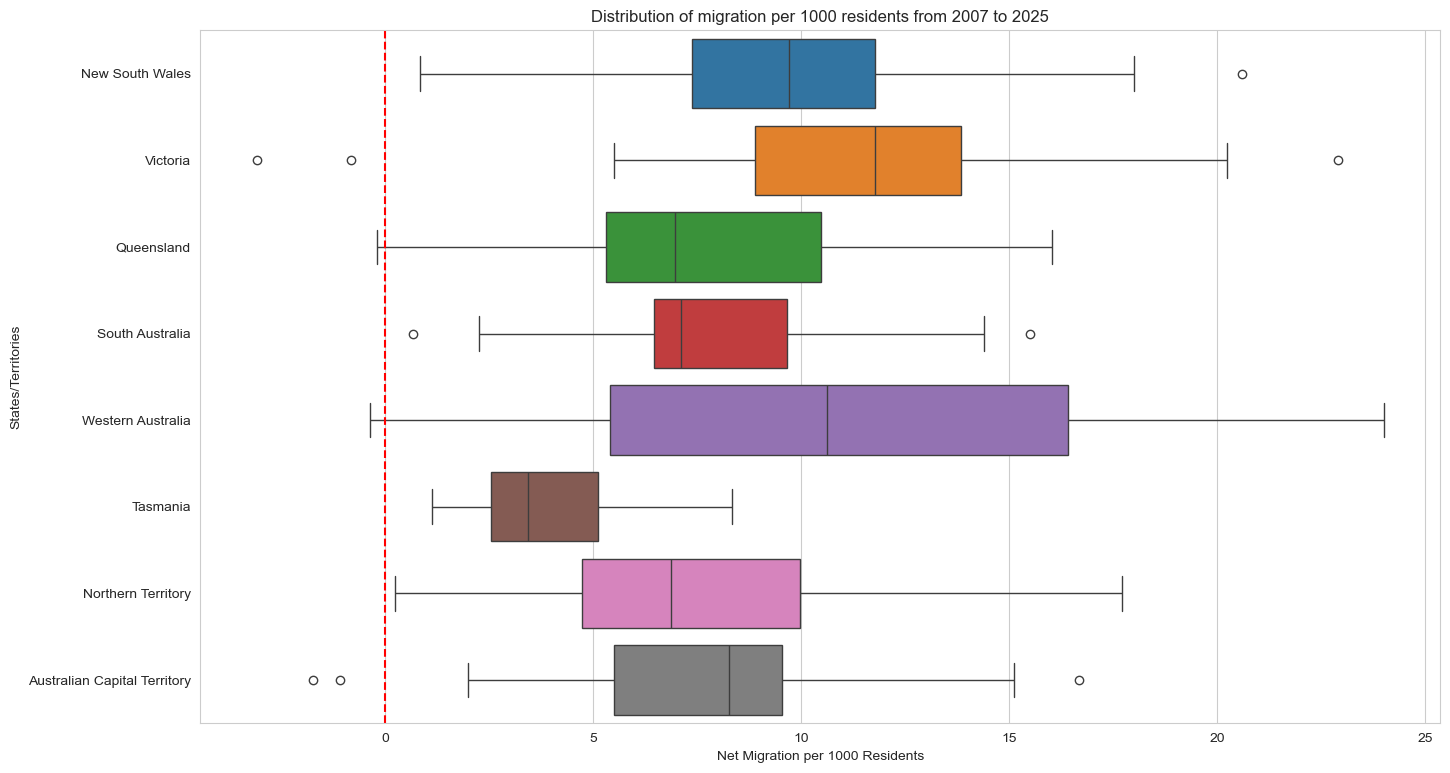

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
fig1, axes1 = plt.subplots(figsize=(16, 9))
sns.boxplot(data=migration_per_capita, orient='h', ax=axes1)
axes1.set_xlabel('Net Migration per 1000 Residents')
axes1.set_title('Distribution of migration per 1000 residents from 2007 to 2025')
axes1.set_ylabel('States/Territories')

# add a reference line at 0% to easily compare migration of each state to the baseline
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

<h3>Takeaways</h3>
<ul class="body-text" style="list-style-type: dot">
<li>Across all states and territories, <strong>net overseas migration (NOM)</strong> to Australia has been overwhelmingly positive</li>
<li>New South Wales, Victoria and Western Australia are leading the race in NOM.</li>
<li>Western Australia shows the largeset variation in its migration rate over the 18 year reference period while Tasmania is relatively consisent.</li>
</ul>

<h3>How do we expect house prices to behave given the trends with migration?</h3>
<ul class="body-text">
<li>Given Australia's <strong>overwhelmingly positive</strong> intake of migrants, we expect demanded for housing to significantly increase.</li>
<li>Thus, we should see <strong>increases in house prices by significant amounts</strong> across all states, depending on how large their NOM is.
</ul>

<h3>What about outliers?</h3>
<span class="body-text">The code block below shows our steps to calculating the outliers and presenting them.</span>

In [65]:
# calculate the outliers
outlier_data = {'Year': [],'State': [],'Migration Outliers': []}
for state in migration_per_capita.columns:
    # get the lower and upper quartiles
    Q1 = migration_per_capita[state].quantile(0.25)
    Q3 = migration_per_capita[state].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    outliers_series = migration_per_capita[state][(migration_per_capita[state] < lower_fence) | (migration_per_capita[state] > upper_fence)]
    # name: state
    # index: year
    # value: migration
    for i, row in enumerate(outliers_series):
        outlier_data['Year'].append(outliers_series.index[i])
        outlier_data['State'].append(state)
        outlier_data['Migration Outliers'].append(row)
outliers = pd.DataFrame(outlier_data)
outliers.head()

,Year,State,Migration Outliers
0,2023-01-01,New South Wales,20.602205
1,2020-01-01,Victoria,-3.079344
2,2021-01-01,Victoria,-0.818593
3,2023-01-01,Victoria,22.899239
4,2021-01-01,South Australia,0.671252


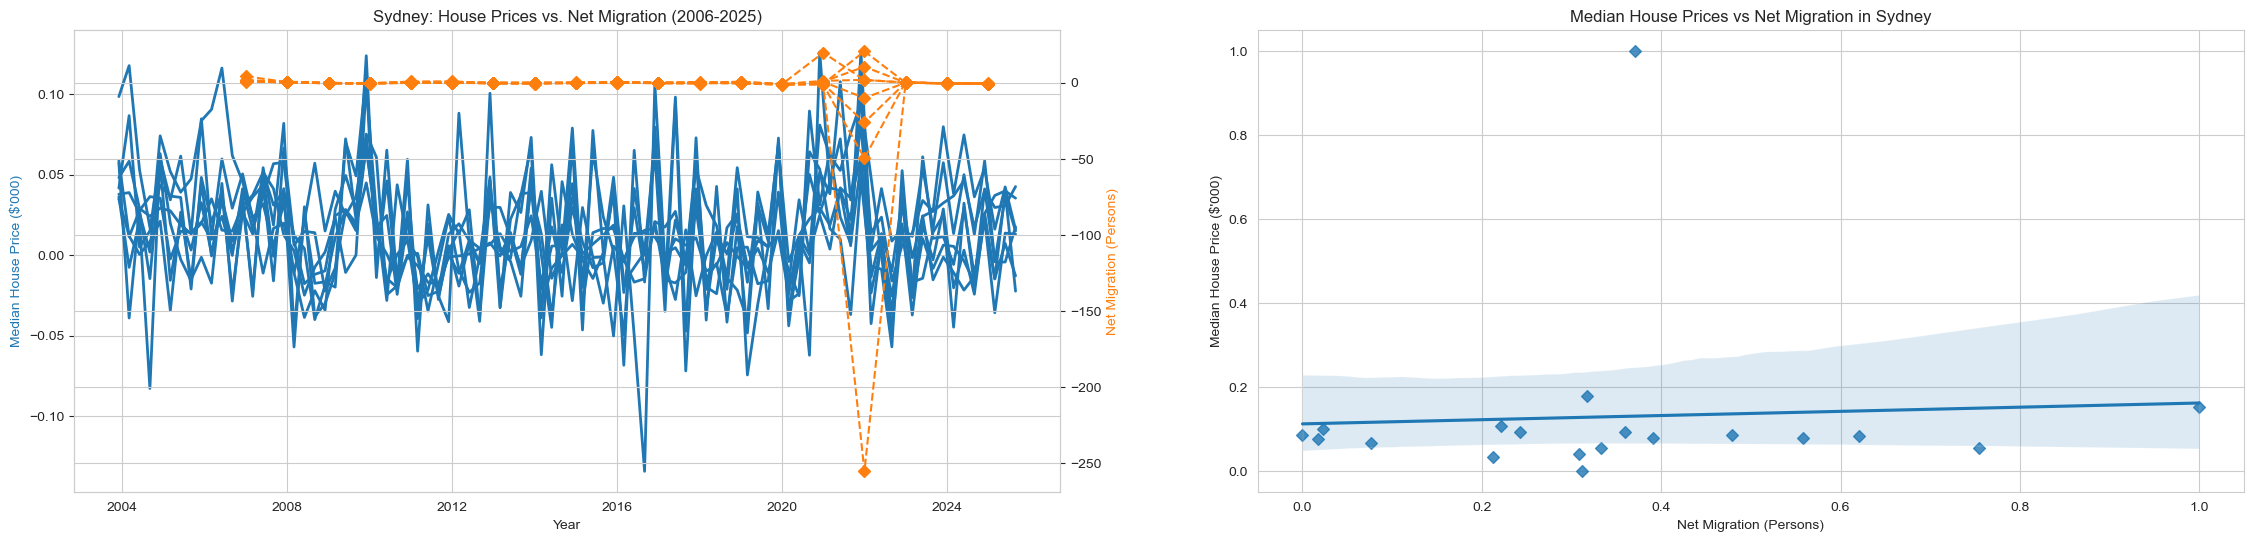

In [79]:
fig2, axes2 = plt.subplots(1, 2, figsize=(28, 6))
# ======= GRAPH 1 =======
# Plotting House Prices on the Left Axis
axes2[0].set_xlabel('Year')
axes2[0].set_ylabel('Median House Price ($\'000)', color='tab:blue')
axes2[0].plot(pct_price_changes.index, pct_price_changes, color='tab:blue', linewidth=2)

# Creating the second axis for Migration
ax2 = axes2[0].twinx()
ax2.set_ylabel('Net Migration (Persons)', color='tab:orange')
ax2.plot(pct_migration_changes.index, pct_migration_changes, color='tab:orange', linestyle='--', marker='D')

# ======= GRAPH 2 =======
# we need to scale the two features as they are of vastly different scales at the moment. A standard min-max scaler will put all values between 0 and 1, allowing for more accurate visualisation of the correlations.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
axes2[1].set_xlabel('Net Migration (Persons)')
axes2[1].set_ylabel('Median House Price ($\'000)')
axes2[1].set_title('Median House Prices vs Net Migration in Sydney')
sns.regplot(x=scaler.fit_transform(pct_price_changes_by_year['NSW'].values.reshape(-1, 1)), y=scaler.fit_transform(pct_migration_changes['New South Wales'].values.reshape(-1, 1)), color='tab:blue', marker='D', ax=axes[1])
plt.title('Sydney: House Prices vs. Net Migration (2006-2025)')
plt.show()

# Calculating the R-squared value for the scatter plot to determine the statistical correlation
#from sklearn.linear_model import LinearRegression
#x=scaler.fit_transform(pct_migration_changes['New South Wales'].values.reshape(-1, 1))
#y=scaler.fit_transform(pct_price_changes['NSW'].values.reshape(-1, 1))
#model = LinearRegression()
#model.fit(x, y)
#r2 = model.score(x, y)
#print('R-squared value:', r2)

## Key Takeaways
1. Housing prices have risen steadily over the last 20 years. This is likely simply due to Australia's chronic issue with housing supply shortages.
2. Net migration dropped steeply in 2020 and stayed low going into 2021. This is most likely due to the COVID-19 pandemic and the lockdowns that had occurred across Australia in this time period.
3. After borders had reopened, net migration skyrocketed to all-time highs due to the backlog of migrants (skilled workers, international students, temporary visa holders) waiting to enter the country.
4. This likely caused an extreme demand shock in the housing market where there was extra competition for buying houses
5. It is known that in the housing industry, it takes some time (1-3 years) for demand shocks to come into full effect for housing prices. For these reasons, Sydney's housing prices have continued to rise heading into 2025.
6. It must also be noted that net migration is not the sole reason for increasing house prices. Australia's **long standing housing supply shorage**, which has existed even prior to the pandemic, is a significant reason why housing prices are still rising. More will be discussed on this later.

## Limitations
- The main limitation with our data is the lack of more data points.
- We had to aggregate the quarterly data for the median prices so they could match the frequency of the net migration data.
- Due to the lack of data points, the confidence interval for our scatter plot is quite wide, suggesting that there is a large uncertainty in how correlated net migration is to median house prices.
- The $R^2$ value being about 0.1 (1 d.p.), in the context of government policy, suggests there is a decent relationship between net migration and median house prices.
- The positive regression line supports the theory that increased net migration does lead to increased median house prices, but should be taken with caution and skepticism due to the low suggested correlation by the $R^2=0.1$ and the fact that many other factors play a part in house prices.
